# Coalescence Neck Curvature Analysis — Cleaned, Self-Contained Version

This notebook is a direct cleanup of the original exploratory notebook
`coalescence neck curvature 100124 used on experimental data 052825_dye.ipynb`.
It preserves the original analysis sequence while removing empty cells,
duplicated fits, hard-coded personal paths, external comparison files, and
out-of-order execution.

The bundled TIFF is synthetic and safe for a public repository.


## Original-to-cleaned workflow

| Original analysis stage | Cleaned implementation |
| --- | --- |
| Load entire TIFF and define hard-coded paths | Stream frames from a repository-relative path |
| Threshold white pixels | `extract_boundaries` |
| Split pixels above/below the midpoint | Explicit `top` and `bottom` interfaces |
| Average duplicate coordinates | `collapse_line_thickness` |
| Crop around discrete extrema | `select_local_window` |
| Repeat the same polynomial fit inside an unused inner loop | One polynomial fit per boundary |
| Different coordinate choices for fitted neck and curvature | Evaluate both at the fitted extremum |
| Save unnamed arrays | Export a labeled frame-level CSV |

Hopper and external comparison CSVs are intentionally excluded because they
are not required for the curvature-extraction pipeline.


## 1. Imports and configuration

All tunable parameters are defined in one place. The path logic works from the
repository root or from the `notebooks/` directory.


In [1]:
from pathlib import Path
from time import perf_counter
import csv

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageSequence

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TIFF_PATH = PROJECT_ROOT / "data" / "michelle0912_sample.tif"
RESULTS_DIR = PROJECT_ROOT / "results"

THRESHOLD = 96
FPS = 200.0
MIDPOINT_Y = None          # None uses half the image height
POLYNOMIAL_DEGREE = 4
FIT_HALF_WIDTH_PX = 7      # 15-point window for integer x-coordinates
MIN_FIT_POINTS = 9


## 2. Stream the TIFF stack

The original notebook loaded every frame into memory. This generator converts
one frame to grayscale at a time, so the memory footprint stays approximately
constant as videos grow.


In [2]:
def tiff_metadata(path):
    with Image.open(path) as image:
        return {
            "frames": int(getattr(image, "n_frames", 1)),
            "width_px": image.width,
            "height_px": image.height,
            "mode": image.mode,
        }


def iter_tiff_frames(path, max_frames=None):
    with Image.open(path) as image:
        for frame_index, frame in enumerate(ImageSequence.Iterator(image)):
            if max_frames is not None and frame_index >= max_frames:
                break
            yield np.asarray(frame.convert("L"), dtype=float)


def read_tiff_frame(path, frame_index):
    with Image.open(path) as image:
        image.seek(frame_index)
        return np.asarray(image.convert("L"), dtype=float)


tiff_metadata(TIFF_PATH)


{'frames': 500, 'width_px': 504, 'height_px': 1008, 'mode': 'RGB'}

## 3. Extract the upper and lower interfaces

Pixels above the intensity threshold are separated around the vertical
midpoint. Anti-aliased line thickness is collapsed by averaging all detected
y-values at each x-coordinate.


In [3]:
def collapse_line_thickness(x, y):
    unique_x, inverse = np.unique(x.astype(int), return_inverse=True)
    counts = np.bincount(inverse)
    mean_y = np.bincount(inverse, weights=y.astype(float)) / counts
    return unique_x.astype(float), mean_y


def extract_boundaries(frame, threshold=THRESHOLD, midpoint_y=MIDPOINT_Y):
    midpoint = frame.shape[0] / 2 if midpoint_y is None else midpoint_y
    y_pixels, x_pixels = np.nonzero(frame >= threshold)

    top_mask = y_pixels < midpoint
    bottom_mask = y_pixels > midpoint
    if top_mask.sum() < MIN_FIT_POINTS or bottom_mask.sum() < MIN_FIT_POINTS:
        raise ValueError("Could not detect both interfaces; adjust the threshold or midpoint.")

    top_x, top_y = collapse_line_thickness(
        x_pixels[top_mask], y_pixels[top_mask]
    )
    bottom_x, bottom_y = collapse_line_thickness(
        x_pixels[bottom_mask], y_pixels[bottom_mask]
    )
    return {
        "top_x": top_x,
        "top_y": top_y,
        "bottom_x": bottom_x,
        "bottom_y": bottom_y,
    }


## 4. Fit each local neck and calculate curvature

For a graph $y(x)$, curvature is

$$
\kappa = \frac{|y''|}{(1+y'^2)^{3/2}}.
$$

Centering x before fitting improves numerical conditioning. The fitted
extremum is selected from the real derivative roots inside the local window.


In [4]:
def select_local_window(x, y, kind, half_width_px=FIT_HALF_WIDTH_PX):
    discrete_index = np.argmax(y) if kind == "maximum" else np.argmin(y)
    center_x = float(x[discrete_index])
    mask = np.abs(x - center_x) <= half_width_px
    if mask.sum() < MIN_FIT_POINTS:
        nearest = np.argsort(np.abs(x - center_x))[:MIN_FIT_POINTS]
        nearest.sort()
        return x[nearest], y[nearest], center_x
    return x[mask], y[mask], center_x


def fit_local_boundary(x, y, kind, degree=POLYNOMIAL_DEGREE):
    local_x, local_y, center_x = select_local_window(x, y, kind)
    local_u = local_x - center_x

    coefficients = np.polyfit(local_u, local_y, degree)
    derivative_1 = np.polyder(coefficients, 1)
    derivative_2 = np.polyder(coefficients, 2)

    roots = np.roots(derivative_1)
    real_roots = np.array(
        [root.real for root in roots if abs(root.imag) < 1e-8]
    )
    valid_roots = real_roots[
        (real_roots >= local_u.min()) & (real_roots <= local_u.max())
    ]

    desired_sign = -1 if kind == "maximum" else 1
    correct_type = np.array([
        root for root in valid_roots
        if desired_sign * np.polyval(derivative_2, root) > 0
    ])
    candidates = correct_type if correct_type.size else valid_roots
    extremum_u = float(candidates[np.argmin(abs(candidates))]) if candidates.size else 0.0

    y_neck = float(np.polyval(coefficients, extremum_u))
    slope = float(np.polyval(derivative_1, extremum_u))
    second_derivative = float(np.polyval(derivative_2, extremum_u))
    curvature = abs(second_derivative) / (1 + slope**2) ** 1.5

    predicted_y = np.polyval(coefficients, local_u)
    fit_rmse = float(np.sqrt(np.mean((predicted_y - local_y) ** 2)))
    fit_u = np.linspace(local_u.min(), local_u.max(), 200)

    return {
        "x_neck": center_x + extremum_u,
        "y_neck": y_neck,
        "curvature_px_inv": float(curvature),
        "rmse_px": fit_rmse,
        "observed_x": local_x,
        "observed_y": local_y,
        "fitted_x": center_x + fit_u,
        "fitted_y": np.polyval(coefficients, fit_u),
    }


## 5. Analyze one frame or the complete stack

Each frame produces labeled measurements rather than parallel arrays. This
makes the exported data auditable and less error-prone.


In [5]:
def analyze_frame(frame, frame_index):
    boundaries = extract_boundaries(frame)
    top_fit = fit_local_boundary(
        boundaries["top_x"], boundaries["top_y"], "maximum"
    )
    bottom_fit = fit_local_boundary(
        boundaries["bottom_x"], boundaries["bottom_y"], "minimum"
    )

    measurement = {
        "frame_index": frame_index,
        "time_s": frame_index / FPS,
        "neck_radius_px": (bottom_fit["y_neck"] - top_fit["y_neck"]) / 2,
        "top_curvature_px_inv": top_fit["curvature_px_inv"],
        "bottom_curvature_px_inv": bottom_fit["curvature_px_inv"],
        "mean_curvature_px_inv": (
            top_fit["curvature_px_inv"] + bottom_fit["curvature_px_inv"]
        ) / 2,
        "top_neck_x_px": top_fit["x_neck"],
        "top_neck_y_px": top_fit["y_neck"],
        "bottom_neck_x_px": bottom_fit["x_neck"],
        "bottom_neck_y_px": bottom_fit["y_neck"],
        "top_fit_rmse_px": top_fit["rmse_px"],
        "bottom_fit_rmse_px": bottom_fit["rmse_px"],
    }
    return measurement, boundaries, top_fit, bottom_fit


def analyze_tiff(path, max_frames=None):
    measurements = []
    for frame_index, frame in enumerate(iter_tiff_frames(path, max_frames)):
        measurement, _, _, _ = analyze_frame(frame, frame_index)
        measurements.append(measurement)
    return measurements


## 6. Validate the curvature calculation

A circle of radius $R$ has curvature $1/R$. This test checks the numerical
fit against that analytical result before the video pipeline is run.


In [6]:
radius = 80.0
x_circle = np.linspace(-15, 15, 61)
y_circle = 100 + np.sqrt(radius**2 - x_circle**2)
circle_fit = fit_local_boundary(x_circle, y_circle, "maximum")

expected_curvature = 1 / radius
relative_error = abs(circle_fit["curvature_px_inv"] - expected_curvature) / expected_curvature
assert relative_error < 0.02

{
    "expected_curvature": expected_curvature,
    "measured_curvature": circle_fit["curvature_px_inv"],
    "relative_error_percent": 100 * relative_error,
}


{'expected_curvature': 0.0125, 'measured_curvature': 0.012499953002031652, 'relative_error_percent': 0.0003759837467892657}

## 7. Run the complete 500-frame analysis


In [7]:
start = perf_counter()
measurements = analyze_tiff(TIFF_PATH)
runtime_s = perf_counter() - start

neck_radius = np.array([row["neck_radius_px"] for row in measurements])
mean_curvature = np.array([row["mean_curvature_px_inv"] for row in measurements])
fit_rmse = np.array([
    (row["top_fit_rmse_px"] + row["bottom_fit_rmse_px"]) / 2
    for row in measurements
])

summary = {
    "frames_analyzed": len(measurements),
    "runtime_s": runtime_s,
    "throughput_frames_per_s": len(measurements) / runtime_s,
    "initial_neck_radius_px": neck_radius[0],
    "final_neck_radius_px": neck_radius[-1],
    "median_fit_rmse_px": np.median(fit_rmse),
}
summary


{'frames_analyzed': 500, 'runtime_s': 5.425987744999929, 'throughput_frames_per_s': 92.14912076805778, 'initial_neck_radius_px': 24.001026441758682, 'final_neck_radius_px': 265.4528369955582, 'median_fit_rmse_px': 0.16863202340929181}

## 8. Visualize bridge growth and curvature evolution


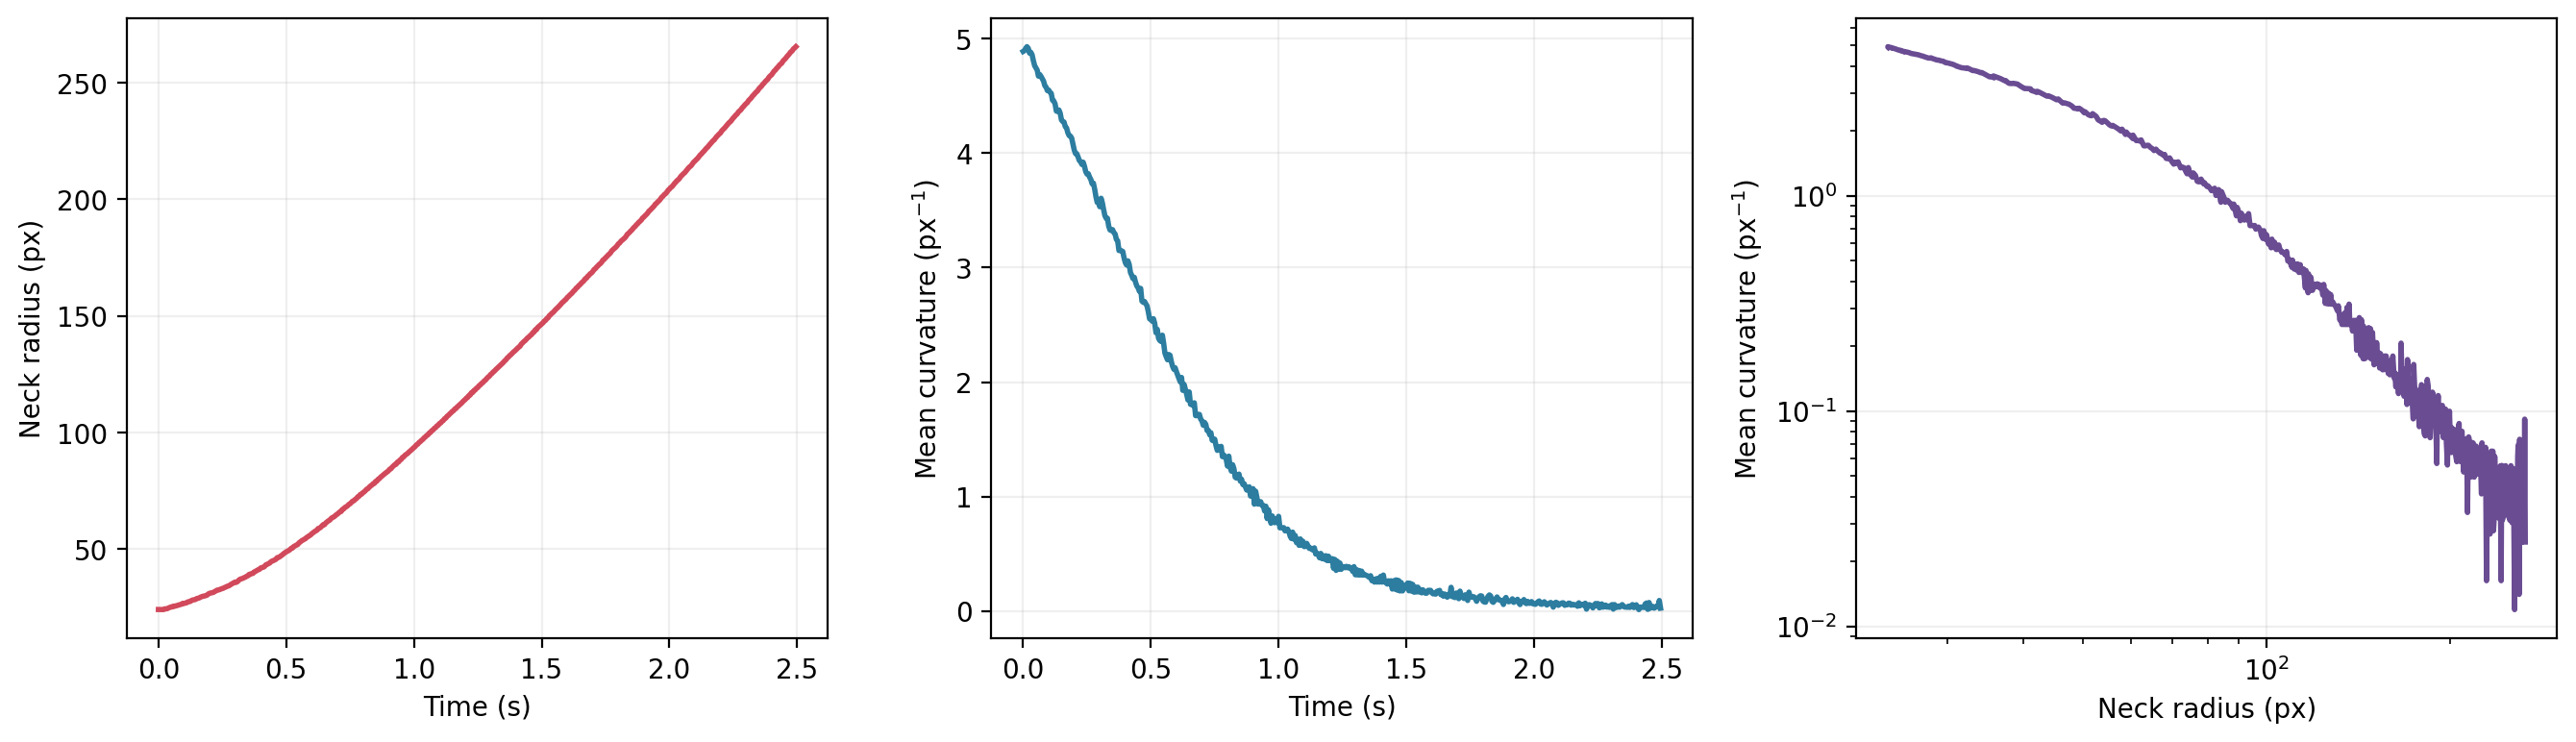

In [8]:
time_s = np.array([row["time_s"] for row in measurements])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
axes[0].plot(time_s, neck_radius, color="#D1495B", linewidth=2)
axes[0].set(xlabel="Time (s)", ylabel="Neck radius (px)")

axes[1].plot(time_s, mean_curvature, color="#2C7DA0", linewidth=2)
axes[1].set(xlabel="Time (s)", ylabel="Mean curvature (px$^{-1}$)")

positive = (neck_radius > 0) & (mean_curvature > 0)
axes[2].loglog(
    neck_radius[positive], mean_curvature[positive],
    color="#6A4C93", linewidth=2
)
axes[2].set(xlabel="Neck radius (px)", ylabel="Mean curvature (px$^{-1}$)")

for axis in axes:
    axis.grid(alpha=0.2)
fig.tight_layout()


## 9. Inspect the local fit on a representative frame


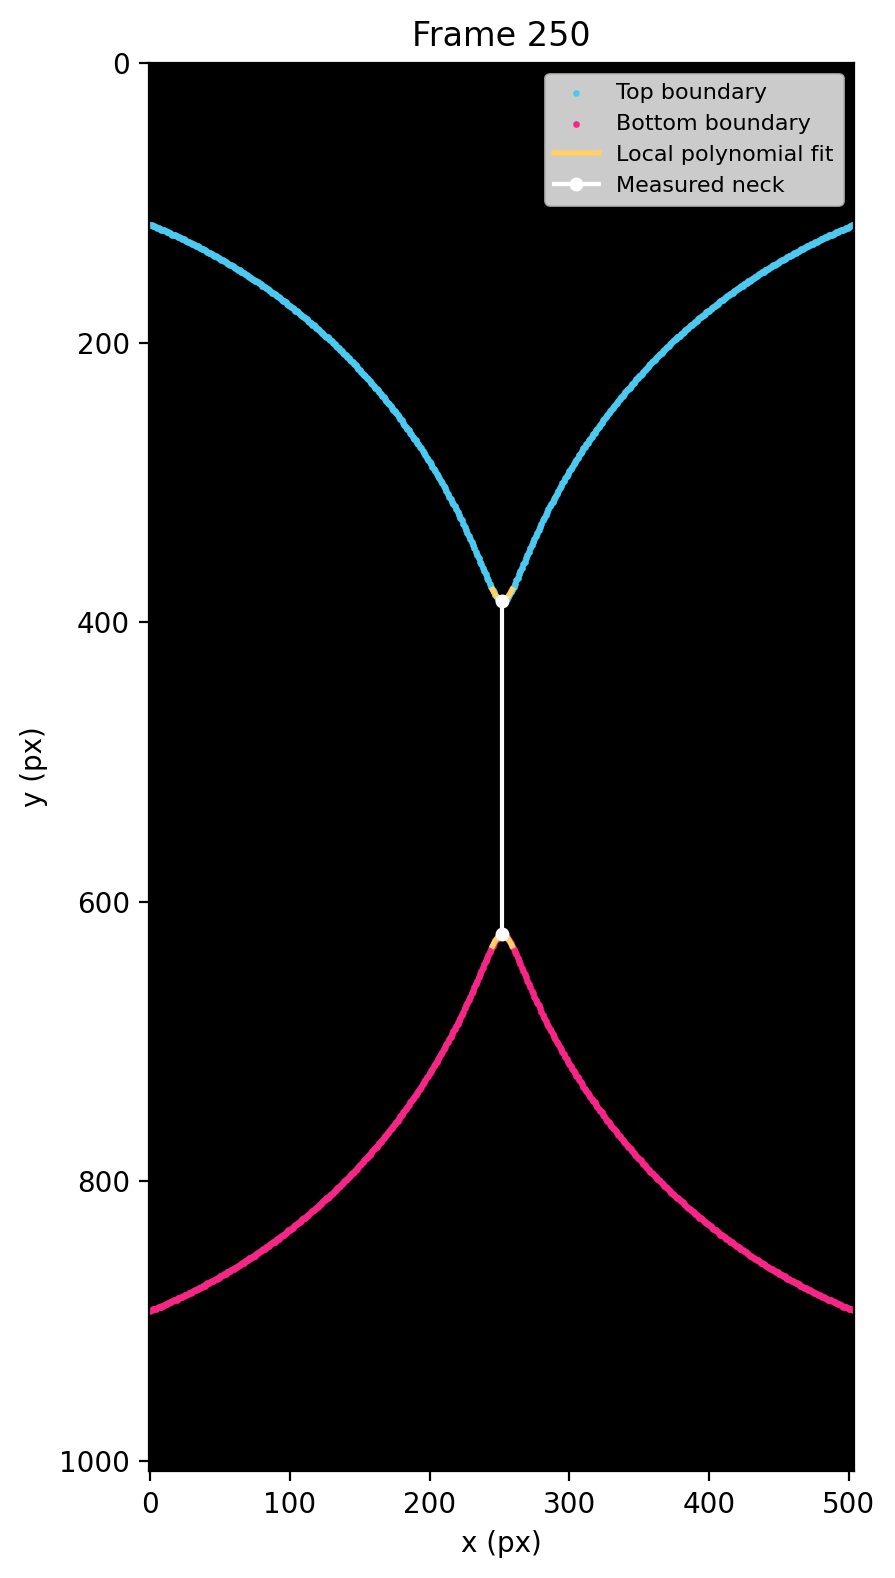

In [9]:
diagnostic_index = 250
diagnostic_frame = read_tiff_frame(TIFF_PATH, diagnostic_index)
measurement, boundaries, top_fit, bottom_fit = analyze_frame(
    diagnostic_frame, diagnostic_index
)

fig, ax = plt.subplots(figsize=(5.2, 8))
ax.imshow(diagnostic_frame, cmap="gray")
ax.scatter(boundaries["top_x"], boundaries["top_y"], s=2, label="Top boundary")
ax.scatter(
    boundaries["bottom_x"], boundaries["bottom_y"], s=2,
    color="#F72585", label="Bottom boundary"
)
ax.plot(top_fit["fitted_x"], top_fit["fitted_y"], color="#FFD166", linewidth=2)
ax.plot(
    bottom_fit["fitted_x"], bottom_fit["fitted_y"],
    color="#FFD166", linewidth=2, label="Local polynomial fit"
)
ax.plot(
    [top_fit["x_neck"], bottom_fit["x_neck"]],
    [top_fit["y_neck"], bottom_fit["y_neck"]],
    color="white", marker="o", linewidth=1.5, label="Measured neck"
)
ax.set(title=f"Frame {diagnostic_index}", xlabel="x (px)", ylabel="y (px)")
ax.legend(loc="upper right")
fig.tight_layout()


In [10]:
measurement


{'frame_index': 250, 'time_s': 1.25, 'neck_radius_px': 119.25638138950825, 'top_curvature_px_inv': 0.38671545173094546, 'bottom_curvature_px_inv': 0.38671545173099725, 'mean_curvature_px_inv': 0.3867154517309713, 'top_neck_x_px': 252.00000000000003, 'top_neck_y_px': 384.7436186104917, 'bottom_neck_x_px': 252.0, 'bottom_neck_y_px': 623.2563813895082, 'top_fit_rmse_px': 0.15886974314209296, 'bottom_fit_rmse_px': 0.15886974314210742}

## 10. Export labeled results


In [11]:
RESULTS_DIR.mkdir(exist_ok=True)
csv_path = RESULTS_DIR / "curvature_measurements_self_contained.csv"

with csv_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=measurements[0].keys())
    writer.writeheader()
    writer.writerows(measurements)

csv_path


PosixPath('results/curvature_measurements_self_contained.csv')

## 11. Verify the refactoring improvement

The original nested loop repeated an identical polynomial fit once per point in
the 15-point local window. The benchmark below compares that exact pattern with
one fit per boundary.


In [12]:
benchmark_windows = []
for frame in iter_tiff_frames(TIFF_PATH, max_frames=100):
    extracted = extract_boundaries(frame)
    for x_values, y_values, kind in (
        (extracted["top_x"], extracted["top_y"], "maximum"),
        (extracted["bottom_x"], extracted["bottom_y"], "minimum"),
    ):
        local_x, local_y, center_x = select_local_window(x_values, y_values, kind)
        benchmark_windows.append((local_x - center_x, local_y))

start = perf_counter()
legacy_calls = 0
for local_x, local_y in benchmark_windows:
    for _ in range(len(local_x)):
        np.polyfit(local_x, local_y, POLYNOMIAL_DEGREE)
        legacy_calls += 1
legacy_runtime = perf_counter() - start

start = perf_counter()
for local_x, local_y in benchmark_windows:
    np.polyfit(local_x, local_y, POLYNOMIAL_DEGREE)
optimized_runtime = perf_counter() - start
optimized_calls = len(benchmark_windows)

{
    "legacy_fit_calls": legacy_calls,
    "optimized_fit_calls": optimized_calls,
    "fit_call_reduction_x": legacy_calls / optimized_calls,
    "measured_fit_stage_speedup_x": legacy_runtime / optimized_runtime,
}


{'legacy_fit_calls': 3000, 'optimized_fit_calls': 200, 'fit_call_reduction_x': 15.0, 'measured_fit_stage_speedup_x': 16.067043838202796}

## Notes for experimental data

- Tune the threshold and midpoint on representative frames.
- Report the polynomial degree and fitting window with the results.
- Examine fit RMSE and diagnostic overlays rather than accepting every frame automatically.
- Add physical pixel calibration and a reference radius only when those quantities are known.
- For noisy interfaces, replace simple thresholding with a more robust segmentation method.
